Задание 1


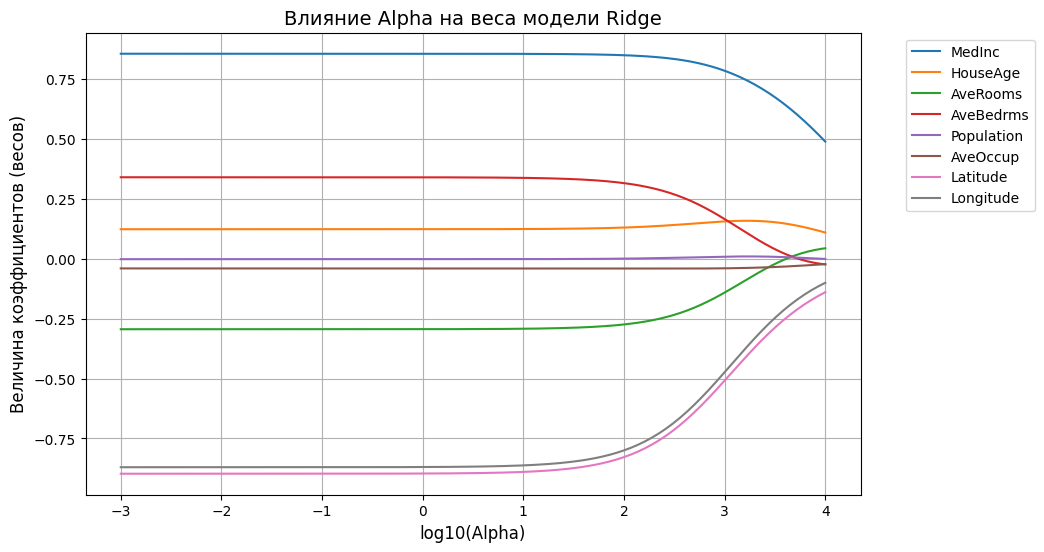

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# 1. Загрузка данных
housing = fetch_california_housing()
X, y = housing.data, housing.target

# 2. Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 4. Перебор значений alpha от 10^-3 до 10^4
alphas = np.logspace(-3, 4, 200)
coefs = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    coefs.append(ridge.coef_)

# 5. Визуализация
plt.figure(figsize=(10, 6))
plt.plot(np.log10(alphas), coefs)
plt.grid(True)
plt.title('Влияние Alpha на веса модели Ridge', fontsize=14)
plt.xlabel('log10(Alpha)', fontsize=12)
plt.ylabel('Величина коэффициентов (весов)', fontsize=12)
plt.legend(housing.feature_names, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

С увеличением силы регуляризации (при движении по оси X вправо, когда lg(a)=0 абсолютные величины всех коэффициентов модели начинают синхронно и плавно уменьшаться, стремясь к нулю

Ни один из коэффициентов не пересёк отметку нуля полностью и не занулился до конца даже при максимальном значении a = 10^4.

Задание 2

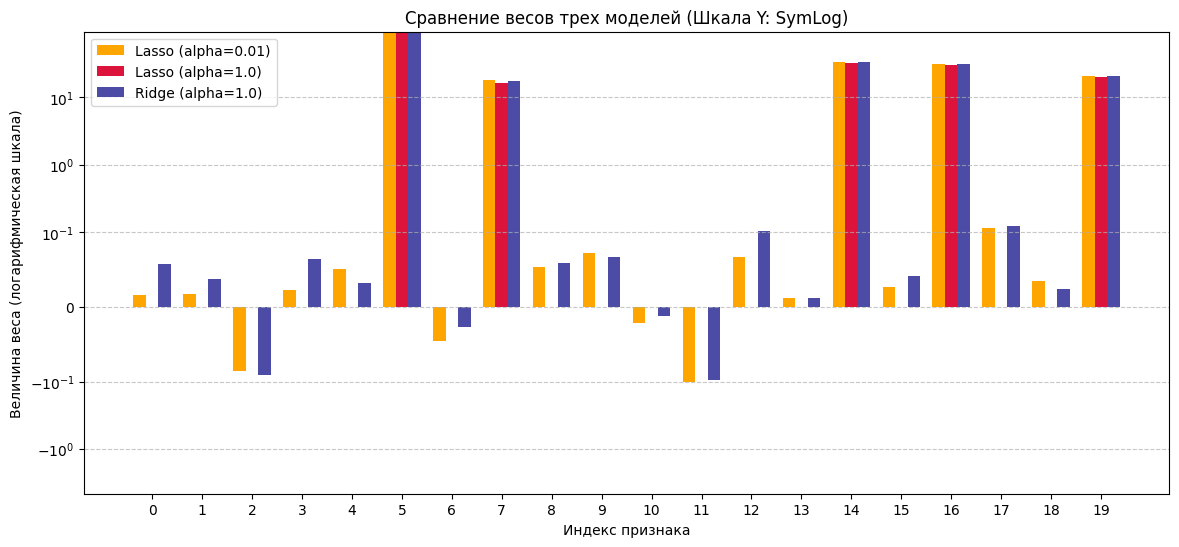

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import Lasso, Ridge

# 1. Создание синтетических данных
X, y = make_regression(n_samples=300, n_features=20, n_informative=5, noise=1.0, random_state=42)

# 2. Обучение всех трех моделей
lasso_small = Lasso(alpha=0.01, random_state=42).fit(X, y)
lasso_large = Lasso(alpha=1.0, random_state=42).fit(X, y)
ridge = Ridge(alpha=1.0, random_state=42).fit(X, y)

# 3. Визуализация весов с тремя группами столбцов
plt.figure(figsize=(14, 6))
width = 0.25  # Уменьшили ширину, чтобы влезло 3 столбца

# Распределяем столбцы по оси X: влево, по центру, вправо
plt.bar(np.arange(20) - width, lasso_small.coef_, width=width, label='Lasso (alpha=0.01)', color='orange')
plt.bar(np.arange(20), lasso_large.coef_, width=width, label='Lasso (alpha=1.0)', color='crimson')
plt.bar(np.arange(20) + width, ridge.coef_, width=width, label='Ridge (alpha=1.0)', color='navy', alpha=0.7)

plt.xticks(np.arange(20))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Симметричный логарифм по оси Y
plt.yscale('symlog', linthresh=0.1)

plt.title('Сравнение весов трех моделей (Шкала Y: SymLog)')
plt.xlabel('Индекс признака')
plt.ylabel('Величина веса (логарифмическая шкала)')
plt.legend()
plt.show()

Lasso при а = 1 обнулил 15/20 весов,оставил только 5 информативно значительно упростив модель, тогда как Ridge при а = 1 не обнулил ни одного.

Задание 3

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, ElasticNet

# 1. Генерация мультиколлинеарных данных
np.random.seed(42)
n_samples = 100
base_feature = np.random.randn(n_samples, 1)

# Создаем 3 почти идентичных признака + 2 шумовых
X_before = np.hstack([
    base_feature,
    base_feature + np.random.normal(0, 0.005, size=(n_samples, 1)),
    base_feature + np.random.normal(0, 0.005, size=(n_samples, 1)),
    np.random.randn(n_samples, 2)
])
y = 10 * base_feature.squeeze() + np.random.normal(0, 0.1, n_samples)

# 2. Моделирование ЖЕСТКОГО шума
X_after = X_before + np.random.normal(0, 0.1, X_before.shape)

# 3. Обучение моделей без шума и с шумом
lasso_before = Lasso(alpha=0.1, random_state=42).fit(X_before, y)
lasso_after  = Lasso(alpha=0.1, random_state=42).fit(X_after, y)

enet_before  = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42).fit(X_before, y)
enet_after   = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42).fit(X_after, y)

# 4. Расчет изменения (дельта) весов для оценки стабильности
lasso_diff = np.abs(lasso_before.coef_ - lasso_after.coef_)
enet_diff  = np.abs(enet_before.coef_ - enet_after.coef_)

# Считаем суммарное "метание" весов по всей модели
total_lasso_shift = np.sum(lasso_diff)
total_enet_shift = np.sum(enet_diff)

# 5. Красивый вывод результатов таблицей
columns = [f'Признак {i+1} (Коррелированный)' if i < 3 else f'Признак {i+1} (Случайный шум)' for i in range(5)]
df_res = pd.DataFrame({
    'Lasso ДО': lasso_before.coef_,
    'Lasso ПОСЛЕ': lasso_after.coef_,
    'Lasso Разница (Abs)': lasso_diff,
    'Elastic ДО': enet_before.coef_,
    'Elastic ПОСЛЕ': enet_after.coef_,
    'Elastic Разница (Abs)': enet_diff
}, index=columns).round(3)

print("="*90)
print(f"СРАВНИТЕЛЬНЫЙ АНАЛИЗ ВЕСОВ ПРИ УВЕЛИЧЕННОМ ШУМЕ (СТАНДАРТНОЕ ОТКЛОНЕНИЕ = 0.1)")
print("="*90)
print(df_res.to_string())
print("="*90)
print(f"Общее суммарное изменение весов у Lasso:       {total_lasso_shift:.4f}")
print(f"Общее суммарное изменение весов у Elastic Net: {total_enet_shift:.4f}")
print("="*90)
lasso_pct = (np.linalg.norm(lasso_before.coef_ - lasso_after.coef_) / np.linalg.norm(lasso_before.coef_)) * 100
enet_pct = (np.linalg.norm(enet_before.coef_ - enet_after.coef_) / np.linalg.norm(enet_before.coef_)) * 100

print(f"Процентное изменение весов Lasso:       {lasso_pct:.2f}%")
print(f"Процентное изменение весов Elastic Net: {enet_pct:.2f}%")

СРАВНИТЕЛЬНЫЙ АНАЛИЗ ВЕСОВ ПРИ УВЕЛИЧЕННОМ ШУМЕ (СТАНДАРТНОЕ ОТКЛОНЕНИЕ = 0.1)
                             Lasso ДО  Lasso ПОСЛЕ  Lasso Разница (Abs)  Elastic ДО  Elastic ПОСЛЕ  Elastic Разница (Abs)
Признак 1 (Коррелированный)     9.862        3.477                6.385       3.241          3.269                  0.028
Признак 2 (Коррелированный)     0.000        3.205                3.205       3.235          3.224                  0.011
Признак 3 (Коррелированный)     0.000        3.137                3.137       3.247          3.192                  0.056
Признак 4 (Случайный шум)      -0.000       -0.001                0.001      -0.000         -0.043                  0.043
Признак 5 (Случайный шум)      -0.000        0.000                0.000      -0.000          0.000                  0.000
Общее суммарное изменение весов у Lasso:       12.7280
Общее суммарное изменение весов у Elastic Net: 0.1380
Процентное изменение весов Lasso:       79.12%
Процентное изменение весов Elasti

При добавлении шума в условиях мультиколлинеарности веса Lasso критически исказились на 79.12%, что делает модель нестабильной. Elastic Net устоял и изменился всего на 1.37%, доказав превосходство гибридной регуляризации на зашумленных данных.

ВАРИАНТ 6

Зад 1

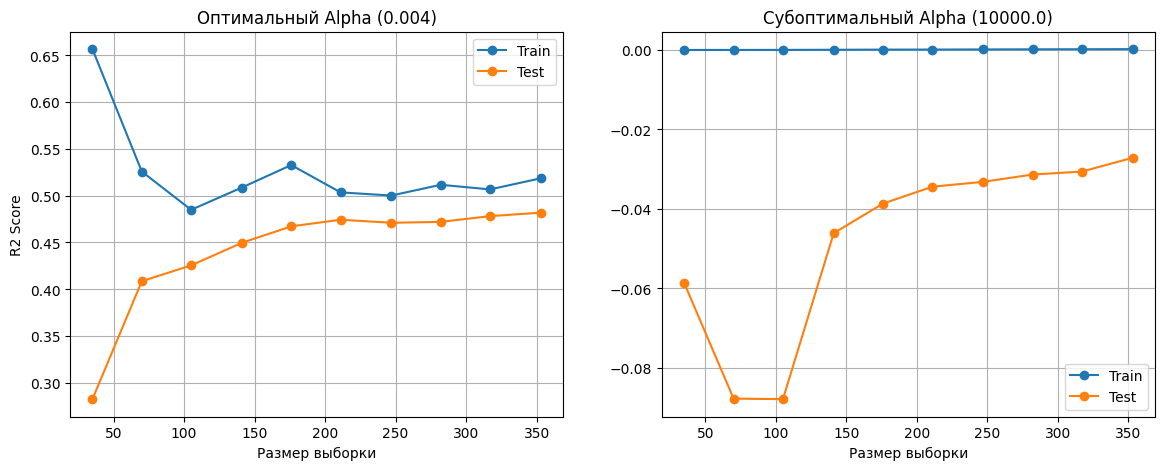

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import learning_curve

# 1. Загрузка данных
X, y = load_diabetes(return_X_y=True)

# 2. Поиск оптимального alpha и выбор худшего
ridge_cv = RidgeCV(alphas=np.logspace(-4, 4, 100)).fit(X, y)
alpha_opt = ridge_cv.alpha_
alpha_sub = 1e4  # Заведомо огромный штраф (плохой score)

# 3. Расчет кривых обучения
def get_lc(model):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='r2'
    )
    return train_sizes, np.mean(train_scores, axis=1), np.mean(test_scores, axis=1)

ts_opt, tr_opt, te_opt = get_lc(Ridge(alpha=alpha_opt))
ts_sub, tr_sub, te_sub = get_lc(Ridge(alpha=alpha_sub))

# 4. График
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(ts_opt, tr_opt, 'o-', label='Train')
ax1.plot(ts_opt, te_opt, 'o-', label='Test')
ax1.set_title(f'Оптимальный Alpha ({alpha_opt:.3f})')
ax1.set_xlabel('Размер выборки'); ax1.set_ylabel('R2 Score'); ax1.grid(); ax1.legend()

ax2.plot(ts_sub, tr_sub, 'o-', label='Train')
ax2.plot(ts_sub, te_sub, 'o-', label='Test')
ax2.set_title(f'Субоптимальный Alpha ({alpha_sub})')
ax2.set_xlabel('Размер выборки'); ax2.grid(); ax2.legend()
plt.show()

Оптимальный параметр a = 0.004 обеспечивает классическую сходимость кривых обучения к хорошему качеству r^2 без признаков переобучения. Cубоптимальный a = 10000 намертво блокирует обучение, удерживая точность на обучающей выборке строго на нуле и уводя тест в отрицательную зону.

Зад 2

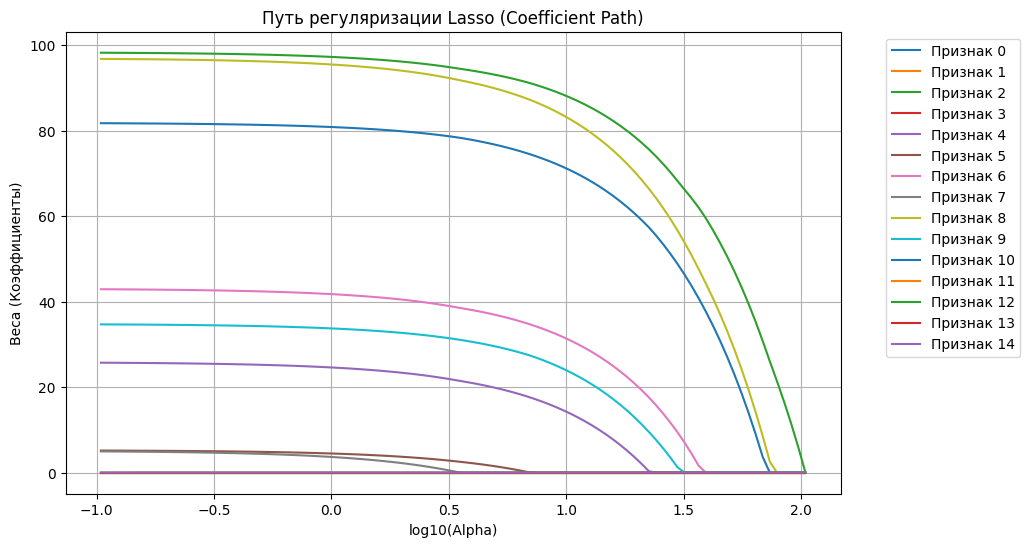

Моменты зануления признаков при увеличении Alpha (движение вправо):
Признак  0 полностью обнуляется при log10(Alpha) >= 1.867
Признак  1 всегда равен нулю
Признак  2 полностью обнуляется при log10(Alpha) >= 2.019
Признак  3 всегда равен нулю
Признак  4 полностью обнуляется при log10(Alpha) >= 1.382
Признак  5 полностью обнуляется при log10(Alpha) >= 0.867
Признак  6 полностью обнуляется при log10(Alpha) >= 1.594
Признак  7 полностью обнуляется при log10(Alpha) >= 0.564
Признак  8 полностью обнуляется при log10(Alpha) >= 1.897
Признак  9 полностью обнуляется при log10(Alpha) >= 1.503
Признак 10 всегда равен нулю
Признак 11 всегда равен нулю
Признак 12 полностью обнуляется при log10(Alpha) >= -0.800
Признак 13 всегда равен нулю
Признак 14 полностью обнуляется при log10(Alpha) >= -0.951


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import lasso_path

# 1. Синтетические данные (15 признаков)
X, y = make_regression(n_samples=200, n_features=15, n_informative=8, noise=1.0, random_state=42)

# 2. Вычисление путей регуляризации Lasso
alphas_path, coefs_path, _ = lasso_path(X, y)

# 3. График траектории коэффициентов
plt.figure(figsize=(10, 6))
n_features = coefs_path.shape[0]
for i in range(n_features):
    plt.plot(np.log10(alphas_path), coefs_path[i], label=f'Признак {i}')

plt.title('Путь регуляризации Lasso (Coefficient Path)')
plt.xlabel('log10(Alpha)')
plt.ylabel('Веса (Коэффициенты)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print("="*60)
print("Моменты зануления признаков при увеличении Alpha (движение вправо):")
print("="*60)
for i in range(n_features):
    # Находим индексы, где вес НЕ равен нулю (еще жив)
    not_zero_indices = np.where(np.abs(coefs_path[i]) > 1e-5)[0]

    if len(not_zero_indices) > 0:
        # Самый первый индекс в массиве, где вес стал нулем при движении справо налево —
        # это индекс ПЕРЕД самым первым ненулевым элементом.
        first_alive_idx = not_zero_indices[0]

        if first_alive_idx > 0:
            # Точка зануления — это шаг прямо перед тем, как признак «ожил»
            zero_idx = first_alive_idx - 1
            print(f"Признак {i:2d} полностью обнуляется при log10(Alpha) >= {np.log10(alphas_path[zero_idx]):.3f}")
        else:
            print(f"Признак {i:2d} не обнулился даже при максимальном Alpha")
    else:
        print(f"Признак {i:2d} всегда равен нулю")

Зад 3

In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, ElasticNet

# 1. Генерация сгруппированных коррелированных признаков (5 групп по 4 признака = 20 всего)
np.random.seed(42)
n_samples = 150
X_groups = []
y = np.zeros(n_samples)

for g in range(5):
    # Базовый признак группы
    base = np.random.randn(n_samples, 1)
    # 4 сильно коррелированных признака внутри группы
    group_feats = base + np.random.normal(0, 0.01, size=(n_samples, 4))
    X_groups.append(group_feats)
    # Пусть только 1-я и 3-я группы реально влияют на y
    if g == 0: y += 5 * base.squeeze()
    if g == 2: y += -3 * base.squeeze()

X = np.hstack(X_groups)
y += np.random.normal(0, 0.1, n_samples)

# 2. Обучение моделей (alpha одинаковый, l1_ratio=0.5 означает гибрид 50/50)
lasso = Lasso(alpha=0.2, random_state=42).fit(X, y)
enet = ElasticNet(alpha=0.2, l1_ratio=0.5, random_state=42).fit(X, y)

# 3. Вывод результатов по группам
df_results = pd.DataFrame({'Lasso': lasso.coef_, 'Elastic Net': enet.coef_})
df_results.index = [f'Гр_{i//4+1}_Пр_{i%4+1}' for i in range(20)]

print("="*50)
print("РАСПРЕДЕЛЕНИЕ ВЕСОВ ПО СГРУППИРОВАННЫМ ПРИЗНАКАМ:")
print("="*50)
print(df_results.round(3).to_string())
print("="*50)

РАСПРЕДЕЛЕНИЕ ВЕСОВ ПО СГРУППИРОВАННЫМ ПРИЗНАКАМ:
           Lasso  Elastic Net
Гр_1_Пр_1  3.821        1.181
Гр_1_Пр_2  0.931        1.187
Гр_1_Пр_3  0.000        1.182
Гр_1_Пр_4  0.000        1.183
Гр_2_Пр_1 -0.000       -0.000
Гр_2_Пр_2 -0.000       -0.000
Гр_2_Пр_3 -0.000       -0.000
Гр_2_Пр_4 -0.000       -0.000
Гр_3_Пр_1 -2.627       -0.705
Гр_3_Пр_2 -0.000       -0.702
Гр_3_Пр_3 -0.000       -0.702
Гр_3_Пр_4 -0.158       -0.703
Гр_4_Пр_1  0.000        0.000
Гр_4_Пр_2  0.000        0.000
Гр_4_Пр_3  0.000        0.000
Гр_4_Пр_4  0.000        0.000
Гр_5_Пр_1  0.000        0.000
Гр_5_Пр_2  0.000        0.000
Гр_5_Пр_3  0.000        0.000
Гр_5_Пр_4  0.000        0.000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.841e-01, tolerance: 4.215e-01
  model = cd_fast.enet_coordinate_descent(


Обе модели успешно идентифицировали неинформативные группы признаков (2, 4, 5) и полностью обнулили их веса, подтвердив эффективность механизмов регуляризации для фильтрации шума. При этом в информативных группах 1 и 3 Lasso распределил веса хаотично, оставив нулевые значения для части полезных переменных, тогда как Elastic Net сгруппировал их равномерно, продемонстрировав корректную работу гибридного метода с сильно связанными данными.